# Bangkok Airbnb EDA
## What Makes a Successful Airbnb Listing in Bangkok?

**Dataset:** Inside Airbnb — Bangkok, Central Thailand (September 2025)  
**Files:** listings.csv.gz, calendar.csv.gz, reviews.csv.gz, neighbourhoods.geojson

### Guiding Questions
1. What drives listing price?
2. Which neighborhoods are most competitive?
3. What makes a high-performing host?
4. How do room type and seasonality affect price and availability?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import geopandas as gpd
import warnings
warnings.filterwarnings('ignore') # suppress pandas/geopandas deprecation warnings
import matplotlib.ticker as ticker
from spicy import stats  # for KDE and statistical overlays

# Plot settings
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_theme(style='whitegrid')

listings = pd.read_csv('../data/listings.csv.gz', compression='gzip')
calendar = pd.read_csv('../data/calendar.csv.gz', compression='gzip')
reviews = pd.read_csv('../data/reviews.csv.gz', compression='gzip')
neighbourhoods = gpd.read_file('../data/neighbourhoods.geojson')

print(f"Listings:      {listings.shape}")
print(f"Calendar:      {calendar.shape}")
print(f"Reviews:       {reviews.shape}")
print(f"Neighbourhoods:{neighbourhoods.shape}")

Listings:      (28806, 79)
Calendar:      (10514202, 7)
Reviews:       (583333, 6)
Neighbourhoods:(50, 3)


In [2]:
# Establish style guide for the entire notebook
COLORS = {
    'primary':    '#2563EB',  # blue — main distributions
    'secondary':  '#F59E0B',  # amber — highlights/annotations
    'accent':     '#10B981',  # green — positive insights
    'neutral':    '#6B7280',  # gray — secondary elements
    'background': '#F8FAFC'   # light gray — figure background
}

FONT = {'family': 'DejaVu Sans', 'size': 11}
plt.rcParams.update({
    'font.family':       FONT['family'],
    'font.size':         FONT['size'],
    'axes.spines.top':   False,  # remove top spine
    'axes.spines.right': False,  # remove right spine — reduces clutter
    'figure.facecolor':  COLORS['background'],
    'axes.facecolor':    COLORS['background'],
})

In [3]:
print(f"Shape: {listings.shape}")
print(f"\nColumn names:\n {listings.columns.tolist()}")

Shape: (28806, 79)

Column names:
 ['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated', 'has_availability', 'availability_30', 'availability

In [4]:
# Categorize columns by type/purpose
col_groups = {
    'identifiers':    ['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'picture_url'],
    'listing_info':   ['name', 'description', 'neighborhood_overview', 'property_type', 'room_type',
                       'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities'],
    'host_info':      ['host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
                       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
                       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
                       'host_neighbourhood', 'host_listings_count', 'host_total_listings_count',
                       'host_verifications', 'host_has_profile_pic', 'host_identity_verified'],
    'location':       ['neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed',
                       'latitude', 'longitude'],
    'pricing':        ['price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
                       'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights',
                       'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm'],
    'availability':   ['has_availability', 'availability_30', 'availability_60', 'availability_90',
                       'availability_365', 'availability_eoy', 'calendar_updated', 'calendar_last_scraped'],
    'reviews':        ['number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d',
                       'number_of_reviews_ly', 'first_review', 'last_review', 'review_scores_rating',
                       'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin',
                       'review_scores_communication', 'review_scores_location', 'review_scores_value',
                       'reviews_per_month'],
    'business':       ['license', 'instant_bookable', 'calculated_host_listings_count',
                       'calculated_host_listings_count_entire_homes',
                       'calculated_host_listings_count_private_rooms',
                       'calculated_host_listings_count_shared_rooms',
                       'estimated_occupancy_l365d', 'estimated_revenue_l365d']
}

for group, cols in col_groups.items():
    print(f"{group.upper():20} ({len(cols)} cols): {cols[:4]}{'...' if len(cols) > 4 else ''}")

IDENTIFIERS          (6 cols): ['id', 'listing_url', 'scrape_id', 'last_scraped']...
LISTING_INFO         (11 cols): ['name', 'description', 'neighborhood_overview', 'property_type']...
HOST_INFO            (18 cols): ['host_id', 'host_url', 'host_name', 'host_since']...
LOCATION             (5 cols): ['neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude']...
PRICING              (9 cols): ['price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights']...
AVAILABILITY         (8 cols): ['has_availability', 'availability_30', 'availability_60', 'availability_90']...
REVIEWS              (14 cols): ['number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'number_of_reviews_ly']...
BUSINESS             (8 cols): ['license', 'instant_bookable', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes']...


In [5]:
print("DATA TYPES")
print(listings.dtypes.value_counts())
print(f"\nTotal columns: {listings.shape[1]}")

DATA TYPES
str        34
float64    25
int64      20
Name: count, dtype: int64

Total columns: 79


In [6]:
missing=listings.isnull().sum()
missing_pct=(missing / len(listings) * 100).round(1)
missing_df=pd.DataFrame({'missing_count': missing, 
                         'missing_pct': missing_pct
                         }).query('missing_count>0').sort_values('missing_pct', ascending=False)
print(f"Columns WITH missing values: {len(missing_df)} out of {listings.shape[1]}")
print(f"Columns with NO missing values: {listings.shape[1] - len(missing_df)}\n")
print(missing_df.to_string())


Columns WITH missing values: 43 out of 79
Columns with NO missing values: 36

                              missing_count  missing_pct
license                               28806        100.0
calendar_updated                      28806        100.0
neighbourhood_group_cleansed          28806        100.0
host_neighbourhood                    19436         67.5
neighborhood_overview                 19322         67.1
neighbourhood                         19322         67.1
host_about                            11990         41.6
review_scores_cleanliness             10091         35.0
reviews_per_month                     10090         35.0
review_scores_value                   10096         35.0
first_review                          10090         35.0
review_scores_rating                  10090         35.0
review_scores_accuracy                10090         35.0
review_scores_checkin                 10093         35.0
review_scores_communication           10091         35.0
review_sco

In [7]:
cols_to_drop = [
    'license',                      # 100% missing
    'calendar_updated',             # 100% missing
    'neighbourhood_group_cleansed', # 100% missing
    'neighbourhood',                # 67% missing — neighbourhood_cleansed is better
    'listing_url',                  # not needed for analysis
    'scrape_id',                    # metadata
    'picture_url',                  # metadata
    'host_url',                     # metadata
    'host_thumbnail_url',           # metadata
    'host_picture_url',             # metadata
]

listings = listings.drop(columns=cols_to_drop)
print(f"Columns after dropping: {listings.shape[1]}")
print(f"Dropped: {len(cols_to_drop)} columns")

Columns after dropping: 69
Dropped: 10 columns


In [8]:
# Check what price looks like before cleaning
print(listings['price'].dtype)
print(listings['price'].head(10))

str
0    $1,595.00
1          NaN
2          NaN
3    $4,188.00
4    $1,450.00
5    $1,368.00
6          NaN
7    $5,600.00
8    $1,147.00
9    $1,416.00
Name: price, dtype: str


In [9]:
# Clean price column
listings['price'] = (listings['price']
                     .str.replace('$', '', regex=False)
                     .str.replace(',', '', regex=False)
                     .astype(float))

# Check result
print(f"dtype after cleaning: {listings['price'].dtype}")
print(f"Missing prices: {listings['price'].isnull().sum()}")
print(f"\nPrice statistics:")
print(listings['price'].describe().round(2))

dtype after cleaning: float64
Missing prices: 5533

Price statistics:
count      23273.00
mean        2528.75
std        16473.90
min            4.00
25%          923.00
50%         1379.00
75%         2207.00
max      1000000.00
Name: price, dtype: float64


In [10]:
# Investigate outliers
print("Listings with price > 50,000 THB:")
print(listings[listings['price'] > 50000][['name', 'price', 'room_type', 'accommodates']].sort_values('price', ascending=False).head(10))

print(f"\nListings with price < 100 THB:")
print(listings[listings['price'] < 100][['name', 'price', 'room_type', 'accommodates']].head(10))

Listings with price > 50,000 THB:
                                                    name      price  \
979                   Modern,wifi,5m MRT&2 Shopping Mall  1000000.0   
1442                  2 Bedroom,wifi,5mMRT&Shopping Mall  1000000.0   
1946   Resort Style Luxury apartment,5min to MRT,free...  1000000.0   
3723        Modern&Luxury apartment,5min to MRT,freeWifi  1000000.0   
3276                       Ideo verse ratchaprarop condo   928572.0   
4676                                     Gemma Sukhumvit   860000.0   
15326  Loft Green Bangkok Couple or Friends Room (Max 3)   433108.0   
26664                        A comfy Home in Central BKK   321829.0   
12719                       Siri Sala Private Thai Villa   184368.0   
5162   【ExLN:9min to BTS/MRT&Terminal21,Big Balcony,Q...   153014.0   

             room_type  accommodates  
979    Entire home/apt             4  
1442   Entire home/apt             5  
1946   Entire home/apt             7  
3723   Entire home/apt      

In [11]:
# Remove outliers — keep only realistic prices
# Lower bound: 100 THB (~$3 USD) — anything below is likely a test listing
# Upper bound: 50,000 THB (~$1,400 USD) — captures luxury without data errors
# The 1,000,000 THB listings appear to be placeholder/error prices by the same host

price_lower = 100
price_upper = 50000

listings_clean = listings[
    (listings['price'] >= price_lower) &
    (listings['price'] <= price_upper)
].copy()  # .copy() prevents SettingWithCopyWarning on future modifications

print(f"Listings before outlier removal: {len(listings)}")
print(f"Listings after outlier removal:  {len(listings_clean)}")
print(f"Removed: {len(listings) - len(listings_clean)} listings ({((len(listings) - len(listings_clean)) / len(listings) * 100):.1f}%)")
print(f"\nPrice range after cleaning: {listings_clean['price'].min()} — {listings_clean['price'].max()} THB")
print(f"New mean:   {listings_clean['price'].mean():.0f} THB")
print(f"New median: {listings_clean['price'].median():.0f} THB")

Listings before outlier removal: 28806
Listings after outlier removal:  23233
Removed: 5573 listings (19.3%)

Price range after cleaning: 122.0 — 50000.0 THB
New mean:   2141 THB
New median: 1378 THB


### Data Cleaning Decisions

| Column | Issue | Action | Reason |
|--------|-------|--------|--------|
| `license`, `calendar_updated`, `neighbourhood_group_cleansed` | 100% missing | Dropped | No analytical value |
| `neighbourhood` | 67% missing | Dropped | `neighbourhood_cleansed` is the clean version |
| 8 URL/metadata columns | Not needed for analysis | Dropped | Reduce noise |
| `price` | Stored as string with `$` and `,` | Converted to float | Required for any numeric analysis |
| `price` < 100 THB | Likely test/error listings | Removed | Not realistic rental prices |
| `price` > 50,000 THB | Data entry errors or placeholders | Removed | Distort distributions and averages |

**Working dataset: 23,233 listings × 69 columns**  
**Price range: 122 — 50,000 THB**  
**Note:** ~35% of listings have no review scores — these are new listings, not bad data. They are kept in the dataset but excluded from review-based analysis.

## Section 2 — Price Analysis
**Question: What drives listing price in Bangkok?**

We'll analyze:
- How prices are distributed
- Which features correlate most with price
- What the key price drivers are

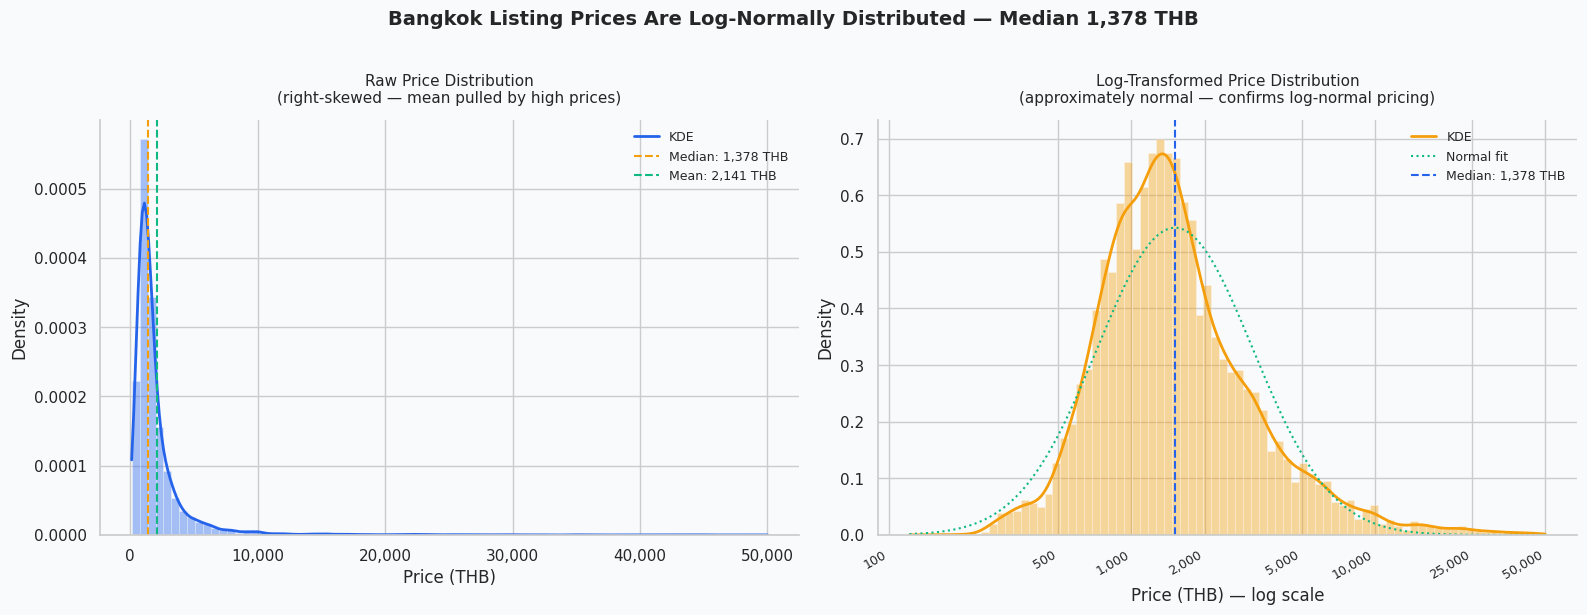

Skewness (raw):           6.86  (>1 = heavily right-skewed)
Skewness (log-transform): 0.86  (near 0 = approximately normal)


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Bangkok Listing Prices Are Log-Normally Distributed — Median 1,378 THB',
             fontsize=14, fontweight='bold', y=1.02)

# --- LEFT: Raw distribution with KDE ---
ax = axes[0]
price_data = listings_clean['price'].dropna()

ax.hist(price_data, bins=80, density=True,
        color=COLORS['primary'], alpha=0.4, edgecolor='white', linewidth=0.5)

kde_x = np.linspace(price_data.min(), price_data.max(), 300)
kde = stats.gaussian_kde(price_data)
ax.plot(kde_x, kde(kde_x), color=COLORS['primary'], linewidth=2, label='KDE')

median_price = price_data.median()
mean_price = price_data.mean()
ax.axvline(median_price, color=COLORS['secondary'], linewidth=1.5,
           linestyle='--', label=f'Median: {median_price:,.0f} THB')
ax.axvline(mean_price, color=COLORS['accent'], linewidth=1.5,
           linestyle='--', label=f'Mean: {mean_price:,.0f} THB')

ax.set_title('Raw Price Distribution\n(right-skewed — mean pulled by high prices)',
             fontsize=11, pad=12)
ax.set_xlabel('Price (THB)')
ax.set_ylabel('Density')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(frameon=False, fontsize=9)

# --- RIGHT: Log scale with real currency labels ---
ax = axes[1]

# np.log1p(x) = log(1+x) — safely handles prices near 0 without returning -inf
log_price = np.log1p(price_data)

ax.hist(log_price, bins=80, density=True,
        color=COLORS['secondary'], alpha=0.4, edgecolor='white', linewidth=0.5)

kde_x_log = np.linspace(log_price.min(), log_price.max(), 300)
kde_log = stats.gaussian_kde(log_price)
ax.plot(kde_x_log, kde_log(kde_x_log), color=COLORS['secondary'], linewidth=2, label='KDE')

mu, std = log_price.mean(), log_price.std()
normal_curve = stats.norm.pdf(kde_x_log, mu, std)
ax.plot(kde_x_log, normal_curve, color=COLORS['accent'], linewidth=1.5,
        linestyle=':', label='Normal fit')

ax.axvline(mu, color=COLORS['primary'], linewidth=1.5,
           linestyle='--', label=f'Median: {median_price:,.0f} THB')

# Convert log tick positions back to real THB values for human readability
tick_positions = np.log1p([100, 500, 1000, 2000, 5000, 10000, 25000, 50000])
tick_labels = ['100', '500', '1,000', '2,000', '5,000', '10,000', '25,000', '50,000']
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=30, ha='right', fontsize=9)

ax.set_title('Log-Transformed Price Distribution\n(approximately normal — confirms log-normal pricing)',
             fontsize=11, pad=12)
ax.set_xlabel('Price (THB) — log scale')
ax.set_ylabel('Density')
ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

print(f"Skewness (raw):           {price_data.skew():.2f}  (>1 = heavily right-skewed)")
print(f"Skewness (log-transform): {log_price.skew():.2f}  (near 0 = approximately normal)")

### Finding 1 — Price Distribution

Bangkok Airbnb prices are heavily right-skewed (skewness = 6.86), with most listings 
priced between 900–2,200 THB/night. The median (1,378 THB) is significantly lower than 
the mean (2,141 THB), indicating a small segment of premium listings pulling the average up.

Log-transformation reduces skewness to 0.86, confirming that prices follow a log-normal 
distribution — a common pattern in economic pricing data. A persistent right tail beyond 
the normal fit suggests a distinct premium listing segment that behaves differently from 
the broader market.

*All subsequent price analysis will use log-transformed values where statistical methods 
assume normality.*

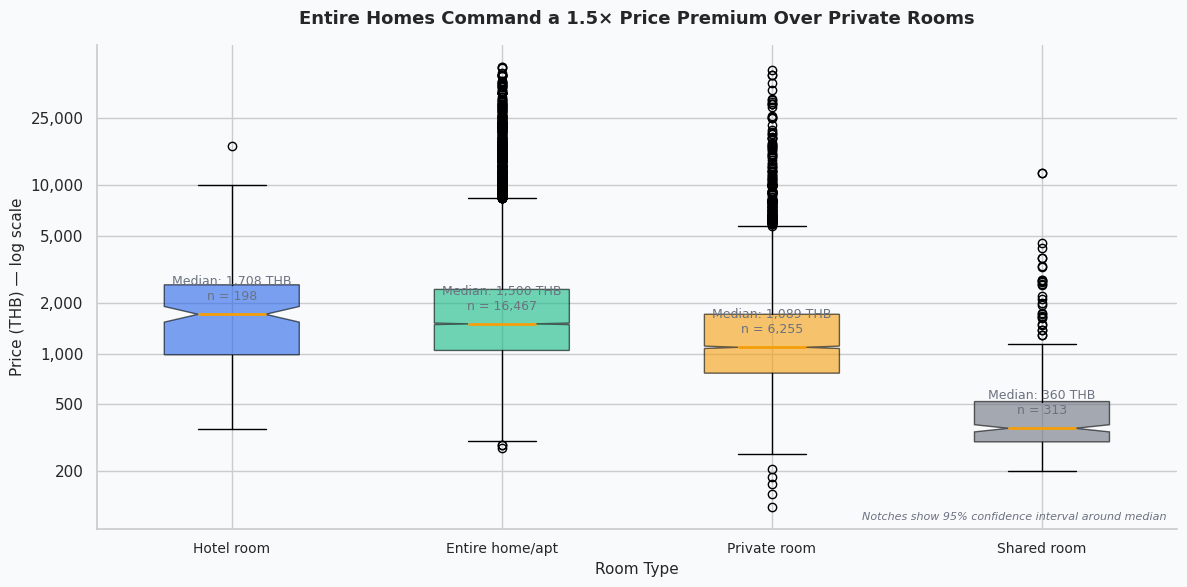

In [15]:
# Price by room type — boxplot with sample size annotations
fig, ax = plt.subplots(figsize=(12, 6))

# Calculate median and count per room type for annotations
room_stats = (listings_clean
              .groupby('room_type')['price']
              .agg(['median', 'count'])
              .sort_values('median', ascending=False))

room_order = room_stats.index.tolist()

# Boxplot on log-transformed price
data_by_room = [np.log1p(listings_clean[listings_clean['room_type'] == r]['price'].dropna())
                for r in room_order]

bp = ax.boxplot(data_by_room,
                patch_artist=True,    # fills boxes with color
                notch=True,           # notch shows 95% CI around median
                vert=True,
                widths=0.5,
                medianprops=dict(color=COLORS['secondary'], linewidth=2))

# Apply color palette to boxes
box_colors = [COLORS['primary'], COLORS['accent'], COLORS['secondary'], COLORS['neutral']]
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# Convert y-axis ticks back to real THB values
tick_positions = np.log1p([200, 500, 1000, 2000, 5000, 10000, 25000])
ax.set_yticks(tick_positions)
ax.set_yticklabels(['200', '500', '1,000', '2,000', '5,000', '10,000', '25,000'])

# Annotate each box with median price and listing count
for i, room in enumerate(room_order):
    median = room_stats.loc[room, 'median']
    count  = room_stats.loc[room, 'count']
    ax.text(i + 1, np.log1p(median) + 0.15,
            f'Median: {median:,.0f} THB\nn = {count:,}',
            ha='center', va='bottom', fontsize=9,
            color=COLORS['neutral'])

ax.set_xticklabels(room_order, fontsize=10)
ax.set_title('Entire Homes Command a 1.5× Price Premium Over Private Rooms',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Room Type', fontsize=11)
ax.set_ylabel('Price (THB) — log scale', fontsize=11)

# Notch explanation for readers unfamiliar with notched boxplots
ax.annotate('Notches show 95% confidence interval around median',
            xy=(0.99, 0.02), xycoords='axes fraction',
            ha='right', fontsize=8, color=COLORS['neutral'], style='italic')

plt.tight_layout()
plt.show()

### Finding 2 — Price by Room Type

Entire homes/apartments dominate the Bangkok market (70% of listings) and command 
a 1.5× price premium over private rooms (median 1,500 vs 989 THB/night). 

Private rooms show the widest price variance, suggesting a split between budget 
guesthouses and premium private-room offerings. Shared rooms (360 THB median) and 
hotel rooms (198 listings) represent niche segments unlikely to affect market-wide 
pricing patterns.

*For subsequent price analysis, entire homes and private rooms will be analyzed 
separately where room type is a confounding variable.*

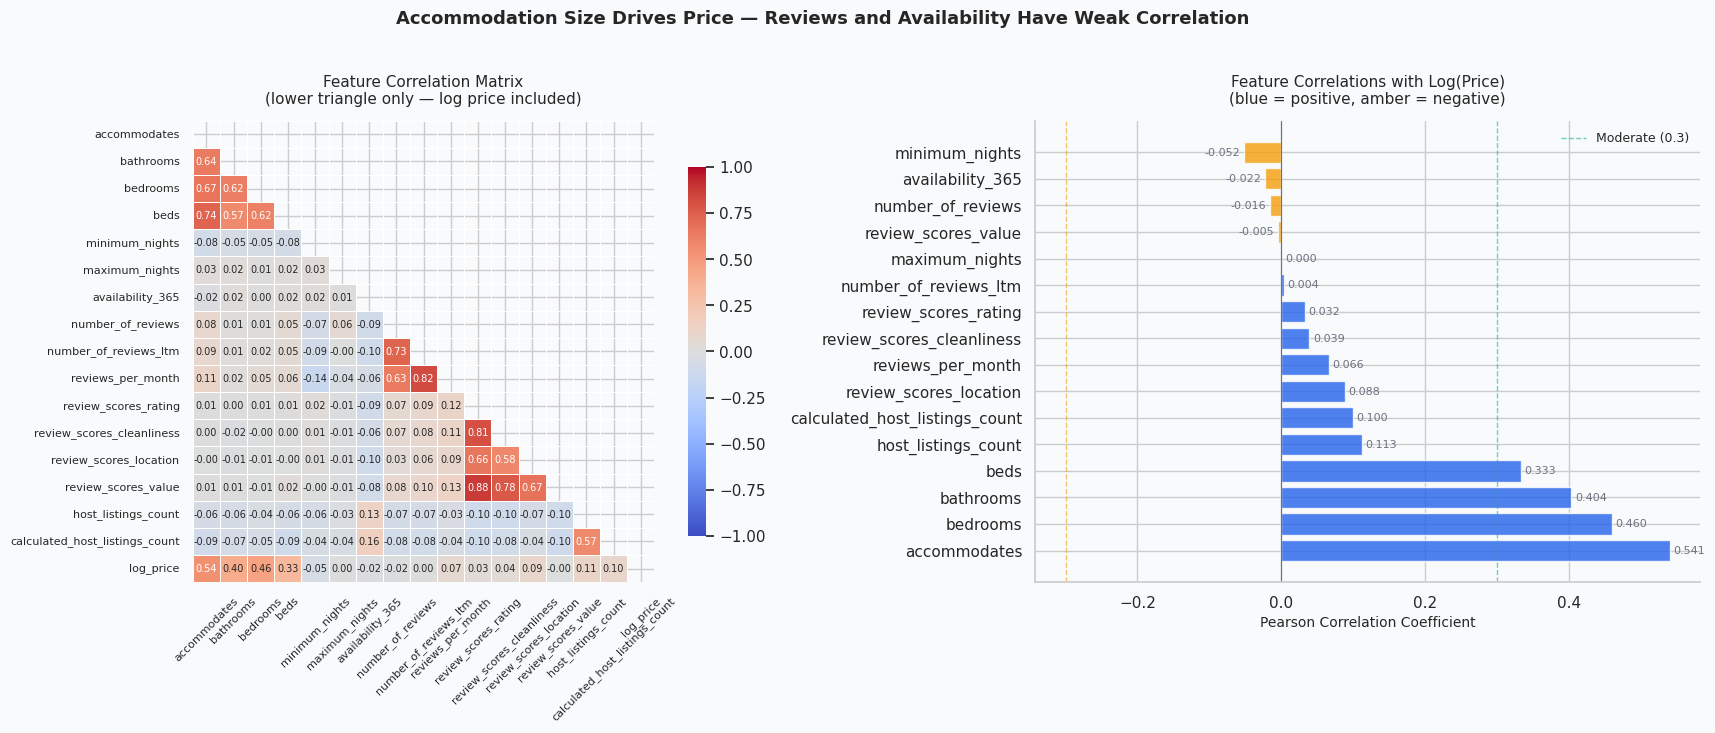

Top positive correlators with price:
accommodates           0.540979
bedrooms               0.459981
bathrooms              0.403838
beds                   0.333355
host_listings_count    0.112593

Top negative correlators with price:
Series([], )


In [16]:
# Select numeric columns relevant to price — exclude IDs, computed duplicates, availability variants
numeric_cols = [
    'price', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'minimum_nights', 'maximum_nights', 'availability_365',
    'number_of_reviews', 'number_of_reviews_ltm', 'reviews_per_month',
    'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_location', 'review_scores_value',
    'host_listings_count', 'calculated_host_listings_count'
]

corr_df = listings_clean[numeric_cols].copy()

# Use log-transformed price for correlation — raw price correlations are 
# suppressed by skewness, log price reveals true linear relationships
corr_df['log_price'] = np.log1p(corr_df['price'])
corr_df = corr_df.drop(columns=['price'])

corr_matrix = corr_df.corr()

# Extract only correlations with log_price, sorted
price_corr = (corr_matrix['log_price']
              .drop('log_price')
              .sort_values(ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- LEFT: Full correlation heatmap ---
ax = axes[0]
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # mask upper triangle — avoid redundancy

sns.heatmap(corr_matrix,
            mask=mask,
            ax=ax,
            cmap='coolwarm',
            center=0,
            vmin=-1, vmax=1,
            annot=True,
            fmt='.2f',
            annot_kws={'size': 7},
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8})

ax.set_title('Feature Correlation Matrix\n(lower triangle only — log price included)',
             fontsize=11, pad=12)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)

# --- RIGHT: Bar chart of correlations with log_price only ---
ax = axes[1]

colors = [COLORS['primary'] if v > 0 else COLORS['secondary'] for v in price_corr.values]
bars = ax.barh(price_corr.index, price_corr.values, color=colors, alpha=0.8, edgecolor='white')

# Annotate each bar with correlation value
for bar, val in zip(bars, price_corr.values):
    ax.text(val + (0.005 if val >= 0 else -0.005),
            bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}',
            va='center',
            ha='left' if val >= 0 else 'right',
            fontsize=8,
            color=COLORS['neutral'])

ax.axvline(0, color=COLORS['neutral'], linewidth=0.8, linestyle='-')

# Threshold lines — weak vs moderate correlation
ax.axvline(0.3,  color=COLORS['accent'],    linewidth=1, linestyle='--', alpha=0.6, label='Moderate (0.3)')
ax.axvline(-0.3, color=COLORS['secondary'], linewidth=1, linestyle='--', alpha=0.6)

ax.set_title('Feature Correlations with Log(Price)\n(blue = positive, amber = negative)',
             fontsize=11, pad=12)
ax.set_xlabel('Pearson Correlation Coefficient', fontsize=10)
ax.legend(frameon=False, fontsize=9)

plt.suptitle('Accommodation Size Drives Price — Reviews and Availability Have Weak Correlation',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print top drivers
print("Top positive correlators with price:")
print(price_corr[price_corr > 0.1].to_string())
print("\nTop negative correlators with price:")
print(price_corr[price_corr < -0.1].to_string())

In [17]:
print("ALL correlations with log_price (sorted):")
print(price_corr.sort_values().to_string())

ALL correlations with log_price (sorted):
minimum_nights                   -0.052346
availability_365                 -0.022485
number_of_reviews                -0.015580
review_scores_value              -0.004873
maximum_nights                    0.000249
number_of_reviews_ltm             0.003759
review_scores_rating              0.032490
review_scores_cleanliness         0.039186
reviews_per_month                 0.066205
review_scores_location            0.088383
calculated_host_listings_count    0.099536
host_listings_count               0.112593
beds                              0.333355
bathrooms                         0.403838
bedrooms                          0.459981
accommodates                      0.540979


### Finding 3 — Price Drivers (Correlation Analysis)

Accommodation size is the dominant price driver in Bangkok's Airbnb market.
The number of guests a listing accommodates (r=0.54), bedrooms (r=0.46),
bathrooms (r=0.40), and beds (r=0.33) are the four strongest correlates of price.

All other features show near-zero correlation with price (|r| < 0.12). Weak negative 
correlations appear for minimum_nights (-0.05) and availability_365 (-0.02), suggesting 
longer-stay and more-available listings price slightly lower — but these effects are 
negligible at the market level.

Review scores show no meaningful price correlation, suggesting quality acts as a 
threshold rather than a continuous price driver.

*Multicollinearity between size features means only one should be used as a predictor 
in any future regression model. `accommodates` is the recommended choice (highest r).*

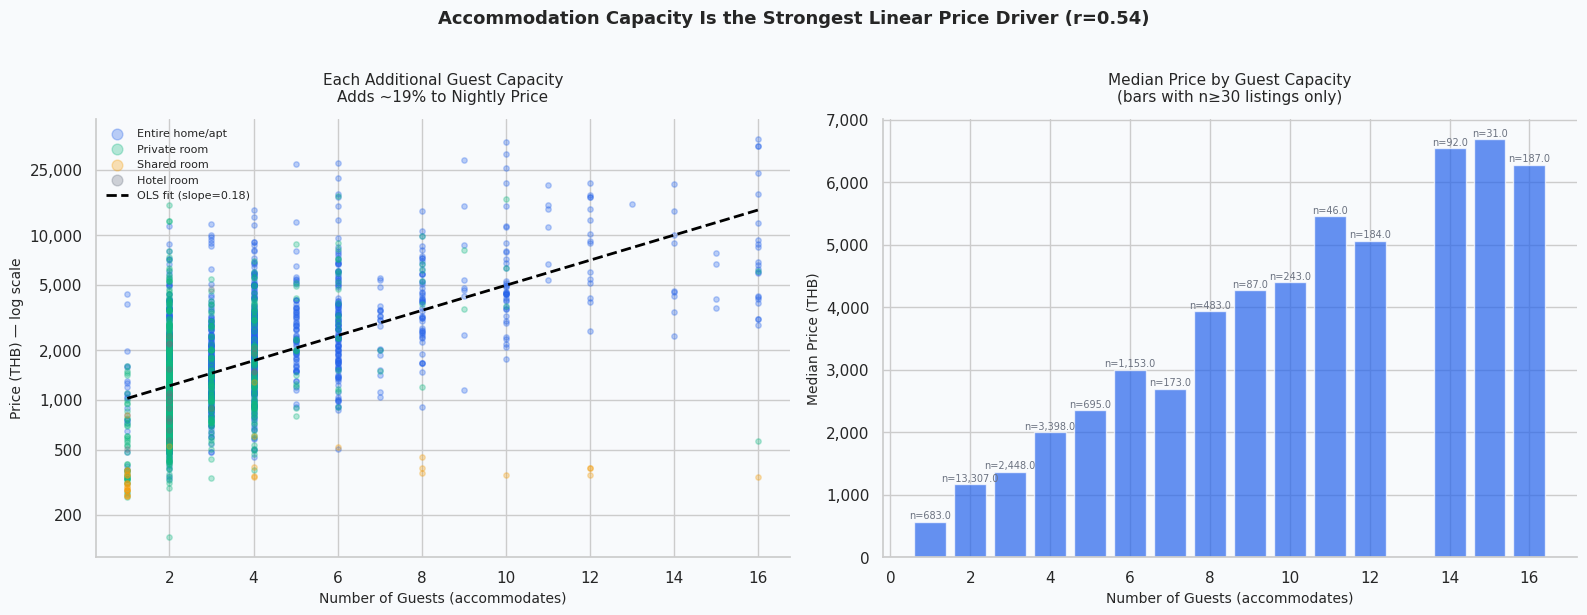

OLS slope: 0.176 in log scale
Interpretation: each additional guest capacity increases price by ~19.2%


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- LEFT: accommodates vs price scatter with regression line ---
ax = axes[0]

# Sample 3000 points — plotting all 23k points creates overplotting
# random_state ensures reproducibility
sample = listings_clean[['accommodates', 'price', 'room_type']].dropna().sample(3000, random_state=42)
log_sample_price = np.log1p(sample['price'])

# Scatter colored by room type
room_types = sample['room_type'].unique()
room_colors = {
    'Entire home/apt': COLORS['primary'],
    'Private room':    COLORS['accent'],
    'Shared room':     COLORS['secondary'],
    'Hotel room':      COLORS['neutral']
}

for room in room_types:
    mask = sample['room_type'] == room
    ax.scatter(sample.loc[mask, 'accommodates'],
               log_sample_price[mask],
               color=room_colors.get(room, COLORS['neutral']),
               alpha=0.3, s=15, label=room)

# OLS regression line
# np.polyfit fits a degree-1 polynomial (straight line) to the data
m, b = np.polyfit(sample['accommodates'], log_sample_price, 1)
x_line = np.linspace(sample['accommodates'].min(), sample['accommodates'].max(), 100)
ax.plot(x_line, m * x_line + b,
        color='black', linewidth=2, linestyle='--', label=f'OLS fit (slope={m:.2f})')

# Convert y ticks to real THB
tick_positions = np.log1p([200, 500, 1000, 2000, 5000, 10000, 25000])
ax.set_yticks(tick_positions)
ax.set_yticklabels(['200', '500', '1,000', '2,000', '5,000', '10,000', '25,000'])

ax.set_title('Each Additional Guest Capacity\nAdds ~19% to Nightly Price',
             fontsize=11, pad=12)
ax.set_xlabel('Number of Guests (accommodates)', fontsize=10)
ax.set_ylabel('Price (THB) — log scale', fontsize=10)
ax.legend(frameon=False, fontsize=8, markerscale=2)

# --- RIGHT: median price per accommodates value ---
ax = axes[1]

median_by_acc = (listings_clean
                 .groupby('accommodates')['price']
                 .agg(['median', 'count'])
                 .reset_index()
                 .query('count >= 30'))  # only show groups with enough data

ax.bar(median_by_acc['accommodates'], median_by_acc['median'],
       color=COLORS['primary'], alpha=0.7, edgecolor='white')

# Annotate count on each bar
for _, row in median_by_acc.iterrows():
    ax.text(row['accommodates'], row['median'] + 50,
            f"n={row['count']:,}",
            ha='center', fontsize=7, color=COLORS['neutral'])

ax.set_title('Median Price by Guest Capacity\n(bars with n≥30 listings only)',
             fontsize=11, pad=12)
ax.set_xlabel('Number of Guests (accommodates)', fontsize=10)
ax.set_ylabel('Median Price (THB)', fontsize=10)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Accommodation Capacity Is the Strongest Linear Price Driver (r=0.54)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Interpret the slope
slope_pct = (np.exp(m) - 1) * 100
print(f"OLS slope: {m:.3f} in log scale")
print(f"Interpretation: each additional guest capacity increases price by ~{slope_pct:.1f}%")

### Finding 4 — Accommodation Capacity vs Price

Each additional guest capacity increases nightly price by approximately 19%, 
confirming accommodates as the strongest linear price driver (r=0.54). 
A listing for 4 guests has a median price of ~1,500 THB vs ~800 THB for 
a solo listing — nearly double.

The relationship holds consistently up to 10 guests but becomes unreliable 
beyond that due to thin sample sizes. Private rooms maintain a price ceiling 
regardless of capacity, suggesting room type acts as an upper bound on what 
the market will pay.